## Overview

This notebook maps methylation-derived genes onto the scRNA-seq UMAP.

Rather than recomputing embeddings, we overlay gene expression scores for genes identified from differential methylation analysis. This allows us to test whether methylation-associated genes align with transcriptional cell states in osteoarthritis.

In [3]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

In [4]:
adata = sc.read_h5ad("../artifacts/scRNA/clustered.h5ad")
adata

AnnData object with n_obs × n_vars = 36205 × 3000
    obs: 'sample', 'condition', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

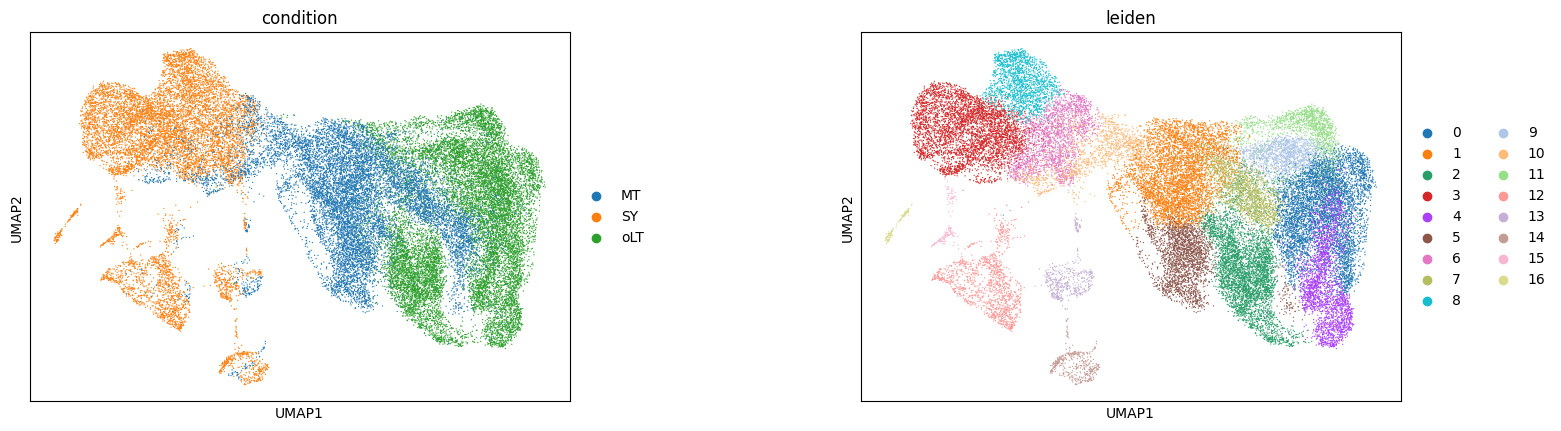

In [5]:
sc.pl.umap(
    adata,
    color=["condition", "leiden"],
    wspace=0.4
)

In [7]:
dmgs = pd.read_csv("../artifacts/methylation/dmgs.csv")
dmgs.head()

,gene,delta_beta,pval
0,ABCA6,-0.221497,0.016593
1,ACSBG1,-0.238600,0.033436
2,AGL,-0.206624,0.031496
3,ALPPL2,-0.261742,0.016710
4,ANKFN1,-0.217444,0.028568


In [10]:
dmgs.columns

Index(['gene', 'delta_beta', 'pval'], dtype='object')

In [11]:
top_dmgs = (
    dmgs
    .assign(abs_delta=lambda x: x["delta_beta"].abs())
    .sort_values("abs_delta", ascending=False)
    .head(50)
)

dmg_genes = [
    g for g in top_dmgs["gene"]
    if g in adata.var_names
]

print("Genes used:", len(dmg_genes))
print(dmg_genes[:10])

Genes used: 6
['RFTN1', 'KCNK17', 'MBP', 'FAM65B', 'CD6', 'DIRC3']


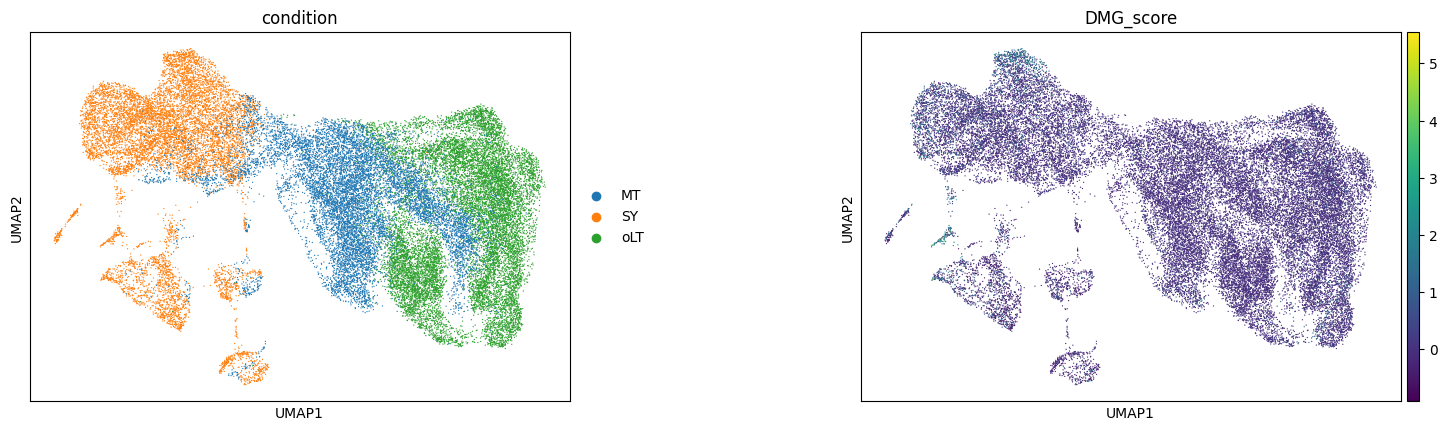

In [12]:
sc.tl.score_genes(
    adata,
    gene_list=dmg_genes,
    score_name="DMG_score"
)

sc.pl.umap(
    adata,
    color=["condition", "DMG_score"],
    cmap="viridis",
    wspace=0.4
)

In [13]:
hyper = top_dmgs[top_dmgs["delta_beta"] > 0]
hypo = top_dmgs[top_dmgs["delta_beta"] < 0]

In [17]:
hyper_genes = [g for g in hyper["gene"] if g in adata.var_names]
hypo_genes  = [g for g in hypo["gene"] if g in adata.var_names]

sc.tl.score_genes(adata, hyper_genes, score_name="hyper_DMG")
sc.tl.score_genes(adata, hypo_genes,  score_name="hypo_DMG")

adata.obs["DMG_score"] = adata.obs["hypo_DMG"] - adata.obs["hyper_DMG"]

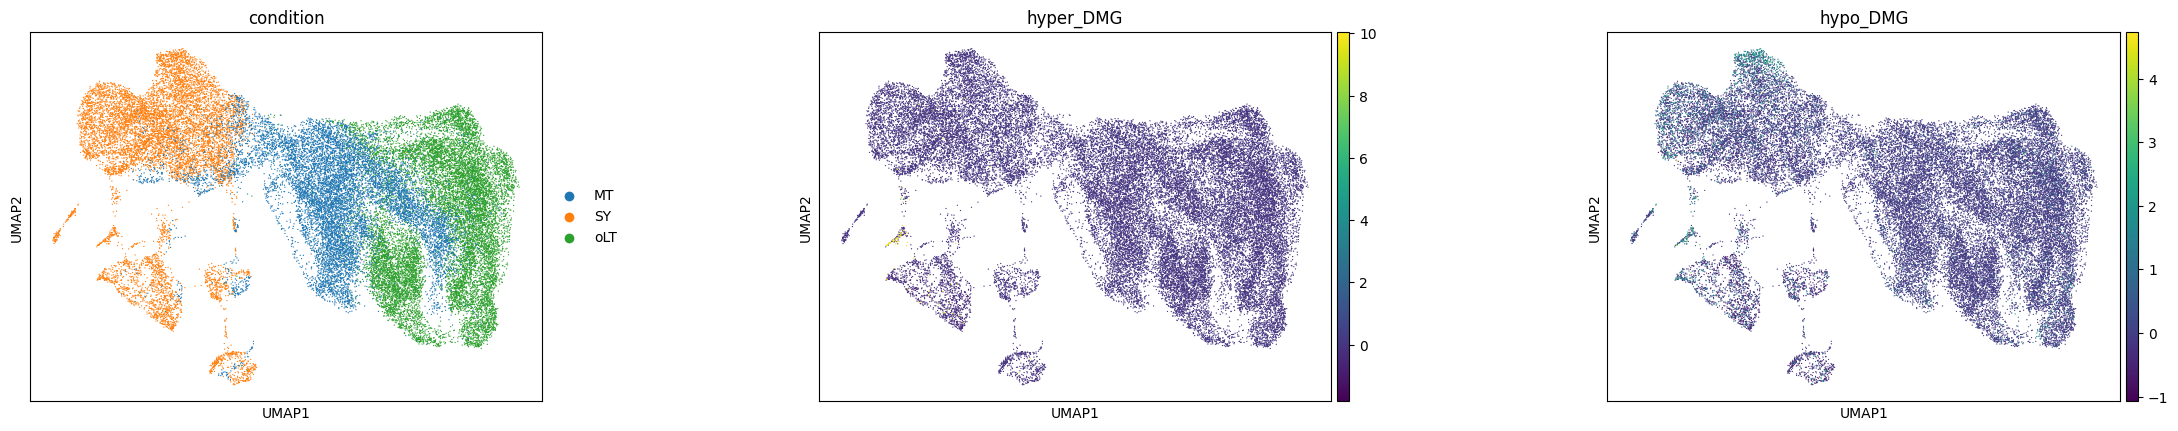

In [18]:
sc.pl.umap(
    adata,
    color=["condition", "hyper_DMG", "hypo_DMG"],
    cmap="viridis",
    wspace=0.4
)